In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_csv('./car_evaluation.csv')
dataset.head(10)

,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,med,high,unacc
6,vhigh,vhigh,2,2,big,low,unacc
7,vhigh,vhigh,2,2,big,med,unacc
8,vhigh,vhigh,2,2,big,high,unacc
9,vhigh,vhigh,2,4,small,low,unacc


In [2]:
dataset['price'].unique

<bound method Series.unique of 0       vhigh
1       vhigh
2       vhigh
3       vhigh
4       vhigh
        ...  
1723      low
1724      low
1725      low
1726      low
1727      low
Name: price, Length: 1728, dtype: str>

<Axes: >

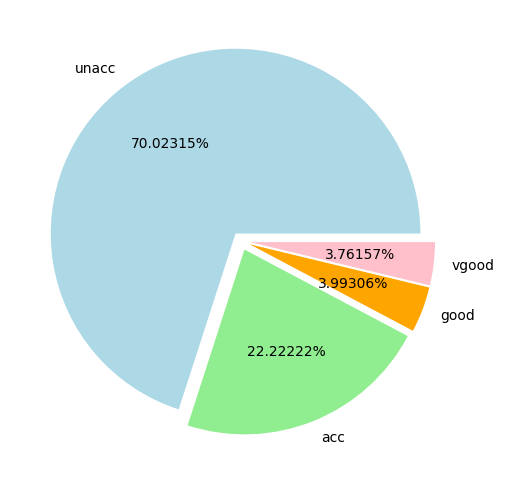

In [3]:
fig_size = plt.rcParams['figure.figsize']
fig_size[0] = 8
fig_size[1] = 6
plt.rcParams["figure.figsize"] = fig_size
dataset.output.value_counts().plot(kind='pie', autopct='%0.05f%%', colors=['lightblue', 'lightgreen', 'orange', 'pink'], explode=(0.05, 0.05, 0.05, 0.05))

In [4]:
categorical_columns = ['price', 'maint', 'doors', 'persons', 'lug_capacity', 'safety']

for category in categorical_columns:
    dataset[category] = dataset[category].astype('category')
    
price = dataset['price'].cat.codes.values
maint = dataset['maint'].cat.codes.values
doors = dataset['doors'].cat.codes.values
persons = dataset['persons'].cat.codes.values
lug_capacity = dataset['lug_capacity'].cat.codes.values
safety = dataset['safety'].cat.codes.values

categorical_data = np.stack([price, maint, doors ,persons, lug_capacity, safety], 1)
categorical_data[:10]

array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

범주형 데이터 -> dataset[category] -> 넘파이 배열 -> Tensor  
즉, 파이토치로 모델을 학습시키기 위해서는 텐서 형태로 변환해야 하는데, 넘파이 배열을 통해 텐서를 생성할 수 있다.  
범주형 데이터 즉, 단어를 숫자로 변환하기 위해 cat.codes를 사용한다. cat.codes는 어떤 클래스를 어떤 숫자로 매핑되어  
있는지 확인이 어려운 단점이 있으므로 주의해서 사용해야 한다.

In [5]:
a = np.array([[1,2], [3,4]])
b = np.array([[5,6], [7,8]])
c = np.array([[5,6], [7,8], [9,10]])

print(np.concatenate((a,b), axis=0)) # <- 4x2
print('------------------------------')
print(np.stack((a,b), axis=1)) # <- 2x2x2

[[1 2]
 [3 4]
 [5 6]
 [7 8]]
------------------------------
[[[1 2]
  [5 6]]

 [[3 4]
  [7 8]]]


In [6]:
print(np.concatenate((a,c), axis=0))

[[ 1  2]
 [ 3  4]
 [ 5  6]
 [ 7  8]
 [ 9 10]]


In [7]:
print(np.stack((a,c), axis=0)) #<- 두 배열 a와 c의 차원이 다르기에 오류 발생

ValueError: all input arrays must have the same shape

In [8]:
categorical_data = torch.tensor(categorical_data, dtype=torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

In [9]:
outputs = pd.get_dummies(dataset.output) # 여기서 get_dummies는 가변수를 만들어 주는 함수이다. 가변수로 만들어 준다는 의미는 숫자 (0, 1)로 바꾸어 준다는 의미이다.
outputs = outputs.values
outputs = torch.tensor(outputs).flatten()

print(categorical_data.shape)
print(outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


In [10]:
import pandas as pd
import numpy as np

data = {
    'gender' : ['male', 'female', 'male'],
    'weight' : [72, 55, 68],
    'nation' : ['Japan', 'Korea', 'Australia']
}

df = pd.DataFrame(data)
df

,gender,weight,nation
0,male,72,Japan
1,female,55,Korea
2,male,68,Australia


In [11]:
pd.get_dummies(df)

,weight,gender_female,gender_male,nation_Australia,nation_Japan,nation_Korea
0,72,False,True,False,True,False
1,55,True,False,False,False,True
2,68,False,True,True,False,False


In [12]:
# revel(), reshape(), flatten() 에 대해 알아보자!
# 얘네는 공통적으로 텐서의 차원을 바꿀때 사용한다!
a = np.array([[1, 2],
              [3, 4]])
print(a.ravel())
print(a.reshape(-1))
print(a.flatten())

[1 2 3 4]
[1 2 3 4]
[1 2 3 4]


워드 임베딩은 유사한 단어끼리 유사하게 인코딩되도록 표현하는 방법이다. 또한, 높은 차원의 임베딩일수록  
단어 간의 세부적인 관계를 잘 파악할 수 있다. 따라서 단일 숫자로 변환된 넘파이 배열을 N차원으로 변경하여  
사용한다.  
배열을 N차원으로 변환하기 위해 먼저 모든 범주형 칼럼에 대한 임베딩 크기를 정의한다. 임베딩 크기에 대한 정확한 규칙은 없지만, 칼럼의 고유 값 수를 2로 나누는 것을 많이 사용함.  
예를 들어, 위에 있는 dataset 데이터에서 price 칼럼은 4개의 고유한 범주값을 갖기 때문에 임베딩 크기는  
4/2 = 2가 된다. 다음 코드를 이용하여 (모든 범주형 칼럼의 고유 값 수, 차원의 크기) 형태로 배열을 만듦

In [13]:
categorical_columns_size = [len(dataset[column].cat.categories) for column in categorical_columns]
categorical_embedding_sizes = [(col_size, min(50, (col_size+1)//2)) for col_size in categorical_columns_size]
print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


In [14]:
total_records = 1728
test_records = int(total_records * .2)

categorical_train_data = categorical_data[:total_records - test_records]
categorical_test_data = categorical_data[total_records - test_records:total_records]
train_outputs = outputs[:total_records - test_records]
test_outputs = outputs[total_records - test_records:total_records]

In [15]:
print(len(categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))

1383
1383
345
345


In [16]:
class Model(nn.Module): # 이렇게 클래스 형태로 구현되는 모델은 nn.Module을 상속받는다
    def __init__(self, embedding_size, output_size, layers, p=0.4): # __init__()은 모델에서 사용될 파라미터와 신경망을 초기화하기 위한 용도로 사용하며, 객체가 생성될 때 자동으로 호출된다.
        # self는 당연히 파이썬의 기본 문법으로 생성자 함수에서 객체 자기 자신을 가리키는 것
        # embedding_size 범주형 칼럼의 임베딩 크기
        # output_size 출력층의 크기
        # layers 모든 계층에 대한 목록이라 하는데 쉽게 말하면 모델의 깊이와 각 층의 크기를 정하는 리스트 입력
        # p는 드롭아웃의 크기 기본 값은 0.4로 현재 지정됨
        super().__init__()  # 부모 클래스에 접근할 때 사용함
        self.all_embeddings = nn.ModuleList([nn.Embedding(ni, nf) for ni, nf in embedding_size])
        
        self.embedding_dropout = nn.Dropout(p)
        
        all_layers = []
        num_categorical_cols = sum((nf for ni, nf in embedding_size))
        input_size = num_categorical_cols
        
        for i in layers: # 
            all_layers.append(nn.Linear(input_size, i))
            all_layers.append(nn.ReLU(inplace=True))
            all_layers.append(nn.BatchNorm1d(i))
            all_layers.append(nn.Dropout(p))
            input_size = i
            
        all_layers.append(nn.Linear(layers[-1], output_size))
        self.layers = nn.Sequential(*all_layers) # 신경망의 모든 계층이 순차적으로 실행되도록 모든 계층에 대한 목록을 nn.Sequential 클래스로 전달
        
    def forward(self, x_categorical): # 학습 데이터를 입력 받아서 연산을 진행
        embeddings = []
        for i, e in enumerate(self.all_embeddings):
            embeddings.append(e(x_categorical[:,i]))
        x = torch.cat(embeddings, 1) # numpy의 concatenate와 같지만 대상이 tensor가 된다
        x = self.embedding_dropout(x)
        x = self.layers(x)
        return x

In [17]:
model = Model(categorical_embedding_sizes, 4, [200, 100, 50], p=0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


모델을 훈련시키기 전에 손실 함수와 옵티마이저에 대해 정의해야 함. 이번 예제는 데이터를 분류해야 하는 것으로  
cross-entropy 손실 함수를 사용한다. 또한, 옵티마이저로는 Adam을 사용한다.

In [18]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [19]:
# 파이토치는 당연히 GPU에 최적화된 딥러닝 프레임워크임. 하지만 GPU가 없다면 CPU를 사용할 수 있도록 지정해야 함.
# 아래 코드는 GPU가 있다면 GPU를 사용하고 없으면 CPU를 사용하는 코드임
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

In [20]:
epochs = 500
aggregated_losses = []
train_outputs = train_outputs.to(device=device, dtype=torch.int64)

for i in range(epochs):
    i +=1 
    y_pred = model(categorical_train_data).to(device)
    single_loss = loss_function(y_pred, train_outputs)
    aggregated_losses.append(single_loss) # 반복할 때마다 오차를 리스트에 추가함
    
    if i % 25 == 1:
        print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')
        
    optimizer.zero_grad()
    single_loss.backward() # 가중치를 업데이트하기 위해 손실함수의 backward() 메서드 호출
    optimizer.step() # 옵티마이저 함수의 step() 메서드를 이용하여 기울기 업데이트
    
print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

epoch:   1 loss: 1.69826829
epoch:  26 loss: 1.45490026
epoch:  51 loss: 1.35939038
epoch:  76 loss: 1.24967587
epoch: 101 loss: 1.12579548
epoch: 126 loss: 0.95612532
epoch: 151 loss: 0.86041987
epoch: 176 loss: 0.76513934
epoch: 201 loss: 0.71887541
epoch: 226 loss: 0.68911326
epoch: 251 loss: 0.64685374
epoch: 276 loss: 0.64419323
epoch: 301 loss: 0.61599082
epoch: 326 loss: 0.60685581
epoch: 351 loss: 0.61143816
epoch: 376 loss: 0.59412378
epoch: 401 loss: 0.59277070
epoch: 426 loss: 0.58754563
epoch: 451 loss: 0.57309109
epoch: 476 loss: 0.58054066
epoch: 500 loss: 0.57459134


In [21]:
test_outputs = test_outputs.to(device=device, dtype=torch.int64)
with torch.no_grad():
    y_val = model(categorical_test_data)
    loss = loss_function(y_val, test_outputs)
    
print(f"Loss: {loss:.8f}") # 테스트 용 데이터셋에 대한 손실 값을 보여줌
# 훈련 데이터에서 도출된 loss 값과 거의 비슷하기에 과적합은 발생하지 않았다고 보면 됨

Loss: 0.58099103


In [22]:
print(y_val[:5]) # 모델이 예측한 가장 확률이 높은 것이 맨 앞에 있음

tensor([[ 2.5769,  1.4328, -3.6630, -3.4319],
        [ 3.9093,  2.2160, -5.2020, -5.5459],
        [ 2.1515,  1.0535, -2.9643, -2.7629],
        [ 2.5908,  1.5743, -2.6648, -2.5413],
        [ 2.9545,  1.6277, -3.4371, -3.3354]])


In [23]:
# 그러나 위에 처럼 보면 어떤 의미인지 이해하기 어렵기에 해당 각각의 행에서 가장 큰 값을 갖는 인덱스를 찾아야함
y_val = np.argmax(y_val, axis=1)
print(y_val[:5])

tensor([0, 0, 0, 0, 0])


위 결과를 보면 모두 인덱스 0이 출력되었음. 즉, 인덱스가 0인 값이 인덱스가 1인 값보다 크므로 처리된 출력이 0임을 확인 가능하다!

In [ ]:
# 마지막으로 sklearn.metrics 모듈의 classification_report, confusion_matrix, accuracy_score 클래스를 사용하여 정확도, 정밀도와 재현율을 알아보자!
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(test_outputs, y_val))
print(classification_report(test_outputs, y_val))
print(accuracy_score(test_outputs, y_val))

[[256   2   1]
 [ 86   0   0]
 [  0   0   0]]
              precision    recall  f1-score   support

           0       0.75      0.99      0.85       259
           1       0.00      0.00      0.00        86
           2       0.00      0.00      0.00         0

    accuracy                           0.74       345
   macro avg       0.25      0.33      0.28       345
weighted avg       0.56      0.74      0.64       345

0.7420289855072464


c:\Users\dhson\Desktop\Pytorch_Study\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dhson\Desktop\Pytorch_Study\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dhson\Desktop\Pytorch_Study\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

: 

마지막으로 딥러닝 분류 모델에서의 성능 평가 지표로는 대표적으로 
- 정확도(Accuracy)  
- 재현율(Recall)
- 정밀도(Precision)
- F1-Score  
가 있음  
정확도 => $\frac{TP+TN}{TP+TN+FP+FN}$  
재현율 => $\frac{TP}{TP+FN}$  
정밀도 => $\frac{TP}{TP+FP}$  
F1-Score => $2 \times \frac{정밀도 \times 재현율}{정밀도 + 재현율}$